In [ ]:
import pandas as pd
import numpy as np
from IPython.display import Image

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
pd.__version__

# Intro

Pandas' groupby is undoubtly one of the most powerful functionalities that Pandas brings to the table. However, most users only utilize a fraction of the capabilities of `groupby`. 

`Groupby` allows to adopt a split-apply-combine approach to your data set. This is comparable to slicing and dicing your data such that it serves your specific need.

On a high level this means:
1. split the data based on column(s)/condition(s) into groups
2. apply a function/transformation to all the groups and combine the results into an output

# 0. Load the data

We are going to use data from a hypothetical sales division where we have, among other columns ficticious sales reps, order leads, order values, the company the deal might happen with and the date of the order lead.

In [ ]:
order_leads = pd.read_csv(
    'https://raw.githubusercontent.com/FBosler/Medium-Data-Exploration/master/order_leads.csv',
    parse_dates = [3]
)
sales_team = pd.read_csv(
    'https://raw.githubusercontent.com/FBosler/Medium-Data-Exploration/master/sales_team.csv',
    
)


In [ ]:
order_leads.head(2)

In [ ]:
sales_team.columns

In [ ]:
order_leads.shape

In [ ]:
order_leads.info()

In [ ]:
sales_team.sample(5)

In [ ]:
sales_team.shape

In [ ]:
sales_team.columns

In [ ]:
sales_team[sales_team['Sales Rep'] == 'Christina Clark']

In [ ]:
order_leads.columns

In [ ]:
sales_team.columns

In [ ]:
print(sales_team.shape)
print(order_leads.shape)

In [ ]:
df = pd.merge(order_leads,sales_team,on=['Company Id','Company Name'])
df.head()
df.shape

In [ ]:
df.Converted.value_counts().values

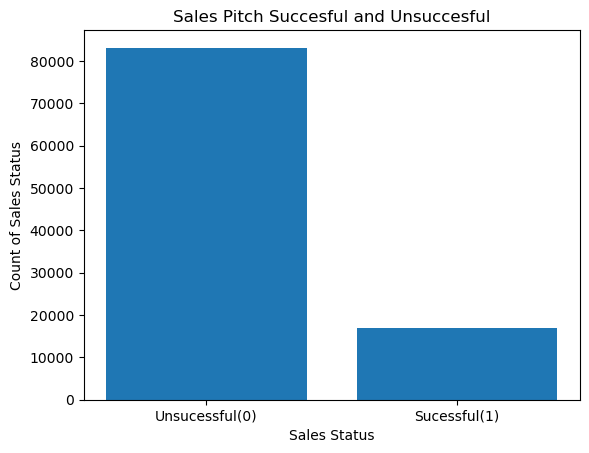

In [82]:
# plot the bar chart of the number of pitches successful and unsucessful.
plt.bar(x=['Unsucessful(0)','Sucessful(1)'],height=df.Converted.value_counts().values)
plt.title("Sales Pitch Succesful and Unsuccesful")
plt.xlabel("Sales Status")
plt.ylabel("Count of Sales Status")
plt.show()

In [ ]:
# plot the bar char of total order value of succ and unsucc pitch
total_order_value_1 = df[df.Converted==1]['Order Value'].sum()
total_order_value_0 = df[df.Converted==0]['Order Value'].sum()
plt.figure(figsize=(10,4))
plt.bar(x=['Total Order Value of Unsucessful Pitches','Total Order Value of Sucessful Pitches'], height=[total_order_value_0,total_order_value_1])
plt.show()

In [ ]:
df.Converted.value_counts()

In [ ]:
df.head(3)

In [69]:
df.head(4)

,Order Id,Company Id,Company Name,Date,Order Value,Converted,Sales Rep,Sales Rep Id
0,HZSXLI1IS9RGABZW,D0AUXPP07H6AVSGD,Melancholy Social-Role,2017-10-13,6952,0,William Taylor,ZTZA0ZLYZR85PTUJ
1,582WPS3OW8T6YT0R,D0AUXPP07H6AVSGD,Melancholy Social-Role,2017-09-02,7930,0,William Taylor,ZTZA0ZLYZR85PTUJ
2,KRF65MQZBOYG4Y9T,D0AUXPP07H6AVSGD,Melancholy Social-Role,2016-12-21,5538,1,William Taylor,ZTZA0ZLYZR85PTUJ
3,N3EDZ5V1WGSWW828,D0AUXPP07H6AVSGD,Melancholy Social-Role,2018-06-03,1113,0,William Taylor,ZTZA0ZLYZR85PTUJ


In [78]:
b = df.groupby("Converted")[['Order Value']].agg(sum)
b

,Order Value
Converted,
0,420582009
1,85712421


In [ ]:
a=df.groupby("Converted")['Order Value'].agg(sum)
a


Converted
0    420582009
1     85712421
Name: Order Value, dtype: int64

Text(0.5, 0, 'X label')

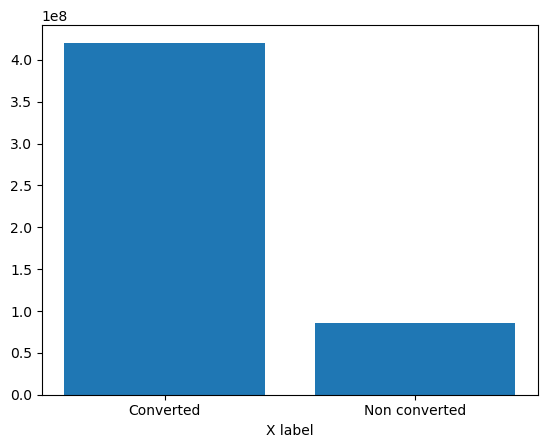

In [85]:
plt.bar(x=['Converted', 'Non converted'],height=a.values)
plt.xlabel('X label')

# 1. Groupby: Split the data based on condition/column into groups

The default approach of calling groupby, is by explicitly providing a column name to split the dataset by. However, and this is less known, you can also pass a Series (has to have the same length as the dataframe) to groupby. 
This means that you can group by a processed version of a column, without having to create a new helper column for that.

### groupby sales rep
First let's create a grouped DataFrame, i.e. split the dataset up.

In [90]:
df.head(2)

,Order Id,Company Id,Company Name,Date,Order Value,Converted,Sales Rep,Sales Rep Id
0,HZSXLI1IS9RGABZW,D0AUXPP07H6AVSGD,Melancholy Social-Role,2017-10-13,6952,0,William Taylor,ZTZA0ZLYZR85PTUJ
1,582WPS3OW8T6YT0R,D0AUXPP07H6AVSGD,Melancholy Social-Role,2017-09-02,7930,0,William Taylor,ZTZA0ZLYZR85PTUJ


In [110]:
df.groupby(['Sales Rep', 'Company Name', 'Converted']).first()

Order Id  \
Sales Rep         Company Name             Converted                     
Aaron Hendrickson 6-Foot Homosexuals       0          LUGEHPZ2HFKLEF1L   
                                           1          WBEX2JZXED721OXI   
                  63D House'S              0          0J72LZBMQJRVSEUZ   
                                           1          C9EDJV3D7FVZW31N   
                  Angular Liberalism       0          3YJD8CFEW9LRGJ2K   
...                                                                ...   
Yvonne Jones      Smarter Java             1          CW3R5CXK4DCF4G92   
Yvonne Lindsey    Meretricious Fabrication 0          93DAW0S29KO0NH0G   
                                           1          7C2OO5J3YO3D99JG   
                  Shrill Co-Op             0          EZXZBVQPW5PWDW40   
                                           1          RDCQ0VCJEF6STBIS   

                                                            Company Id  \
Sales Rep         Company Name             Converted                     
Aaron Hendrickson 6-Foot Homosexuals       0          OBO1IDFAZIVFRG9A   
                                           1          OBO1IDFAZIVFRG9A   
                  63D House'S              0          SPKG45IHYO76EWEA   
                                           1          SPKG45IHYO76EWEA   
                  Angular Liberalism       0          AGFI002RNQTP41KM   
...                                                                ...   
Yvonne Jones      Smarter Java             1          I7K8YY52IKCZ3SXR   
Yvonne Lindsey    Meretricious Fabrication 0          57G8KMLJ4TP42A5V   
                                           1          57G8KMLJ4TP42A5V   
                  Shrill Co-Op             0          IGOZET5TU8NF7FX0   
                                           1          IGOZET5TU8NF7FX0   

                                                           Date  Order Value  \
Sales Rep         Company Name             Converted                           
Aaron Hendrickson 6-Foot Homosexuals       0         2014-04-13         9399   
                                           1         2015-04-08         6005   
                  63D House'S              0         2017-02-13         9932   
                                           1         2018-04-04         3717   
                  Angular Liberalism       0         2016-01-18         1701   
...                                                         ...          ...   
Yvonne Jones      Smarter Java             1         2015-09-29         3290   
Yvonne Lindsey    Meretricious Fabrication 0         2015-08-23         3872   
                                           1         2018-10-27         6735   
                  Shrill Co-Op             0         2018-06-07         1233   
                                           1         2017-08-15         9462   

                                                          Sales Rep Id  
Sales Rep         Company Name             Converted                    
Aaron Hendrickson 6-Foot Homosexuals       0          AEMLQ09IYM72ACBL  
                                           1          AEMLQ09IYM72ACBL  
                  63D House'S              0          AEMLQ09IYM72ACBL  
                                           1          AEMLQ09IYM72ACBL  
                  Angular Liberalism       0          AEMLQ09IYM72ACBL  
...                                                                ...  
Yvonne Jones      Smarter Java             1          GNSJO948HA09N564  
Yvonne Lindsey    Meretricious Fabrication 0          LBSKFCGCB0IZTMWN  
                                           1          LBSKFCGCB0IZTMWN  
                  Shrill Co-Op             0          LBSKFCGCB0IZTMWN  
                                           1          LBSKFCGCB0IZTMWN  

[9105 rows x 5 columns]

In [ ]:
# ended here 

In [96]:
grouped_by_sales_rep = df.groupby(['Sales Rep','Converted'])[['Order Value']].sum()
grouped_by_sales_rep

Order Value
Sales Rep         Converted             
Aaron Hendrickson 0              1332129
                  1               218479
Adam Sawyer       0              1342323
                  1               245505
Adele Kimmel      0               424275
...                                  ...
Willie Sanchez    1               269773
Yvonne Jones      0               332515
                  1                83873
Yvonne Lindsey    0               239328
                  1                85006

[998 rows x 1 columns]

In [105]:
df.groupby('Sales Rep',)['Order Value'].sum().sort_values(ascending=False)

Sales Rep
Alyssa Mckinney     2172439
Jessica Renner      2161540
Elizabeth Gaddy     2147581
Christina Clark     2134452
Fidel Carbo         2115456
                     ...   
Linda Thomas          81914
Ginger Wright         79366
Robert Bowen          70885
Debra Vermillion      63933
Simon Hearn           59732
Name: Order Value, Length: 499, dtype: int64

In [106]:
df[df.Converted==1].groupby('Sales Rep')['Order Value'].sum().sort_values(ascending=True)

Sales Rep
Richard Nicols           305
Beatrice Mccormick      3737
Joan Hutchins           4601
Debra Vermillion        7975
Mary Brooks             8658
                       ...  
Allen Olding          358517
Gerry Meredith        361848
Thomas Huckabaa       371702
Joyce Mitchell        379952
Margaret Lott         385993
Name: Order Value, Length: 499, dtype: int64

In [107]:
df[df.Converted==1].groupby('Sales Rep')['Order Value'].agg([min,max,sum]).sort_values(ascending=False,by='max')

,min,max,sum
Sales Rep,,,
Paula Flores,607,9999,174615
Amy Jernigan,350,9999,102143
Carolyn Rea,281,9997,269767
Gary Castle,1354,9996,42261
Maria Martin,326,9996,134571
...,...,...,...
Debra Vermillion,3613,4362,7975
Mary Brooks,2540,3164,8658
Beatrice Mccormick,1036,2701,3737


### show all groups
calling `groups` on the grouped object returns the list of indices for every group (as every row can be uniquely identified via it's index)

In [108]:
grouped_by_sales_rep.groups

AttributeError: 'DataFrame' object has no attribute 'groups'

In [ ]:
len(grouped_by_sales_rep.groups)

### select a specific group

In [ ]:
grouped_by_sales_rep.get_group('Aaron Hendrickson')

For the following examples we will use the simplest version of the apply step (and just count the rows in each group) via the `size` method. We do this, so that we can focus on the groupby operations. 

We will go into much more detail regarding the apply methods in section 2 of the article. 

### Basic Example: Count rows in each group

In [ ]:
grouped_by_sales_rep.size().sort_values(ascending=False)


In [ ]:
df['Sales Rep'].value_counts()

### Advanced Example: Group by first name of sales rep

In [ ]:
# Grouping by first name of our Sales Rep without creating a column
df.groupby(df['Sales Rep'].str.split(' ').str[0]).size()

### Advanced Example:  Grouping by whether or not there is a "William" in the name of the rep

In [ ]:
df.groupby(df['Sales Rep'].apply(lambda x: 'William' in x)).size()

### Advanced Example: Group by random series (for illustrative purposes only)

In [ ]:
# Grouping random letters (obviously does not make sense)
df.groupby(
    pd.Series(np.random.choice(list('ABCDG'),len(df)))
).size()

### Advanced Example:  Grouping by 3 evenly cut "Order Value" buckets

In [ ]:
# qcut bins the passed Series into q evenly sized parts (and labels the bins)
df.groupby(
    pd.qcut(x=df['Val'],q=3,labels=['low','mid','high'])
).size()

### Advanced Example: Grouping by cutom "Order Value" buckets

In [ ]:
# cut bins the passed Series into defined bins
df.groupby(
    pd.cut(df['Val'],[0,3000,5000,7000,10000])
).size()

## `pd.Grouper`
The biggest "gotcha" in that area for me was understanding pd.Grouper, which allows seamless aggregation on different date/time granularities.


### Advanced Example: Grouping by year

In [ ]:
df.head()

In [ ]:
df.groupby(pd.Grouper(key='Date',freq='Y')).Val.agg('max')

### Advanced Example: Grouping by quarter

In [ ]:
# grouping by year
df.groupby(pd.Grouper(key='Date',freq='SM')).size()

### Advanced Example: Grouping by multiple columns

In [ ]:
df.groupby(['Sales Rep','Company Name']).size()

# 2. Apply and Combine: Apply a function/transformation to all groups and combine the results into an output

In the previous section we discussed how to group the data based on various conditions. This section deals with available functions that we can apply to the groups before combining them to a final result.

The section is structured along how to use
1. apply,
2. agg(regate),
3. transform, and
4. filter,
on a grouped object.

If you are anything like me when I started using groupby, you are probably using a combination of 1. and 2. along the lines of:

`group = df.groupby('GROUP')` and then:
- `group.apply(mean)`
- `group.agg(mean)`
- `group['INTERSTING COLUMN'].apply(mean)`
- `group.agg({'INTERSTING COLUMN':mean})`
- `group.mean()`

Where `mean` could also be another function.

All of them work. And most of the time, the result is going to be roughly what you expected it to be. However, there are nuances to apply and agg that are worthwhile pointing out.

Additionally, but much more importantly there are two lesser-known extremly powerful functions that can be used on a grouped object, `filter` and `transform`.

### `Apply`: Let's get  `apply` out of the way
This is somewhat confusing, as we often talk about applying functions while there also is an apply function. But bear with me. The `apply` function applies a function along an axis of the DataFrame. This could be either column-wise or row-wise.
`apply` is not strictly speaking a function that can only be used in the context of groupby. It could also used on an entire dataframe, like in the following example.

In [ ]:
_ = pd.DataFrame(
    np.random.random((2,6)),
    columns=list('ABCDEF')
)
_

In [ ]:
_.apply(sum, axis=0) # axis=0 is default, so you can drop that

In [ ]:
_.apply(sum, axis=1)

But it can also be used in a groupby context. Which makes sense, considering the fact that each group is a smaller DataFrame on its own. Keep in mind that the function will be applied to the entire DataFrame. This means typically you want to select the columns you are `applying` a function to. We will leave it at these examples and instead focus on `agg(regation)` which is the "intended" way of aggregating groups.

In [ ]:
df.groupby(
    pd.Grouper(key='Date',freq='Y')
)['Sale'].apply(sum)

In [ ]:
df.groupby(
    pd.Grouper(key='Date',freq='Y')
)['Val','Sale'].apply(sum)

In [ ]:
df.groupby(
    pd.Grouper(key='Date',freq='Y')
)['Val','Sale'].apply(sum).to_clipboard(sep=' ')

# `agg(regate)`

In [ ]:
Image(filename='groupby-agg.png') 

In [ ]:
# agg(regation)
df.groupby('Sales Rep')\
\
.agg({
    'Order Id':'size',
    'Val':['sum','mean'],
    'Sale':['sum','mean']
})

In [ ]:
def cr(x):
    return round(np.mean(x),2)

aggregation = {
    'Potential Sales':('Val','size'),
    'Sales':('Sale','sum'),
    'Conversion Rate':('Sale',cr)
}

df.groupby('Sales Rep').agg(**aggregation)

In [ ]:
def cr(x):
    return round(np.mean(x),2)

_ = df.groupby('Sales Rep').agg({
    'Val':'size',
    'Sale':['sum',cr]
})

_.columns = ['Potential Sales','Sales','Conversion Rate']
_

## Transform

In [ ]:
Image(filename='groupby-transform.png') 

In [ ]:
df.groupby('Sales Rep')['Val'].transform(lambda x: x/sum(x))

In [ ]:
df['%'] = df.groupby('Sales Rep')['Val'].transform(
  lambda x: x/sum(x)
)

In [ ]:
del df['%']

In [ ]:
# filter (at least 200k in sales)
df.groupby('Sales Rep').filter(lambda x: (x['Val'] * x['Sale']).sum() > 200000)

In [ ]:
# Let's add this for verification
df['cr'] = df.groupby('Sales Rep')['Sale'].transform('mean')

df.groupby('Sales Rep').filter(lambda x: x['Sale'].mean() > .3)

In [ ]:
del df['cr']

# Advanced Examples Agg

In [ ]:
# Grouping by 3 evenly cut "Order Value" buckets
df.groupby(
    pd.qcut(df['Val'],3,['low','mid','high'])
).agg({'Val':['mean','std'],'Sale':['sum','size']})

In [ ]:
# Grouping by cutom "Order Value" buckets
df.groupby(
    pd.cut(df['Val'],[0,3000,5000,7000,10000])
).agg({'Val':['mean','std'],'Sale':['sum','size']})

In [ ]:
df.groupby(
    pd.cut(df['Val'],[0,5000,10000],labels=['low','high'])
).agg(
    **{'Conversion Rate':pd.NamedAgg(column='Sale',aggfunc=lambda x: sum(x)/len(x))}
)

In [ ]:
# grouping by year and a cut oder value column
df.groupby(
    [pd.Grouper(key='Date',freq='Y'),pd.qcut(df['Val'],3,['low','mid','high'])]
).agg(
    **{'Conversion Rate':pd.NamedAgg(column='Sale',aggfunc=lambda x: sum(x)/len(x))}
).unstack()